In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print ("All imports loaded")

All imports loaded


In [ ]:
from google.colab import files
uploaded = files.upload()

train = pd.read_csv('train.csv')
print(f"Dataset loaded! Shape: {train.shape}")

Saving train.csv to train.csv
Dataset loaded! Shape: (1460, 81)


In [ ]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Number of samples: {train.shape[0]}")
print(f"Number of features: {train.shape[1] - 1} (excluding SalePrice which is our target)")

numerical_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()
numerical_cols.remove('SalePrice')
numerical_cols.remove('Id')

print(f"Numerical features: {len(numerical_cols)}")
print(f"Categorical features: {len(categorical_cols)}")
print()
print("Data types:")
print(train.dtypes.value_counts())
print()
train.head()

DATASET OVERVIEW
Number of samples: 1460
Number of features: 80 (excluding SalePrice which is our target)
Numerical features: 36
Categorical features: 43

Data types:
object     43
int64      35
float64     3
Name: count, dtype: int64



,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
train[numerical_cols].describe().round(2)

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1460.0,1201.00,1460.00,1460.00,1460.00,1460.00,1460.00,1452.00,1460.00,1460.00,...,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00
mean,56.9,70.05,10516.83,6.10,5.58,1971.27,1984.87,103.69,443.64,46.55,...,472.98,94.24,46.66,21.95,3.41,15.06,2.76,43.49,6.32,2007.82
std,42.3,24.28,9981.26,1.38,1.11,30.20,20.65,181.07,456.10,161.32,...,213.80,125.34,66.26,61.12,29.32,55.76,40.18,496.12,2.70,1.33
min,20.0,21.00,1300.00,1.00,1.00,1872.00,1950.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,2006.00
25%,20.0,59.00,7553.50,5.00,5.00,1954.00,1967.00,0.00,0.00,0.00,...,334.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5.00,2007.00
50%,50.0,69.00,9478.50,6.00,5.00,1973.00,1994.00,0.00,383.50,0.00,...,480.00,0.00,25.00,0.00,0.00,0.00,0.00,0.00,6.00,2008.00
75%,70.0,80.00,11601.50,7.00,6.00,2000.00,2004.00,166.00,712.25,0.00,...,576.00,168.00,68.00,0.00,0.00,0.00,0.00,0.00,8.00,2009.00
max,190.0,313.00,215245.00,10.00,9.00,2010.00,2010.00,1600.00,5644.00,1474.00,...,1418.00,857.00,547.00,552.00,508.00,480.00,738.00,15500.00,12.00,2010.00


In [ ]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

print(f"Columns with missing values: {len(missing_df)} out of {train.shape[1]}")
print()
print(missing_df)

Columns with missing values: 19 out of 81

              Missing Count  Missing %
PoolQC                 1453      99.52
MiscFeature            1406      96.30
Alley                  1369      93.77
Fence                  1179      80.75
MasVnrType              872      59.73
FireplaceQu             690      47.26
LotFrontage             259      17.74
GarageType               81       5.55
GarageYrBlt              81       5.55
GarageFinish             81       5.55
GarageQual               81       5.55
GarageCond               81       5.55
BsmtExposure             38       2.60
BsmtFinType2             38       2.60
BsmtQual                 37       2.53
BsmtCond                 37       2.53
BsmtFinType1             37       2.53
MasVnrArea                8       0.55
Electrical                1       0.07


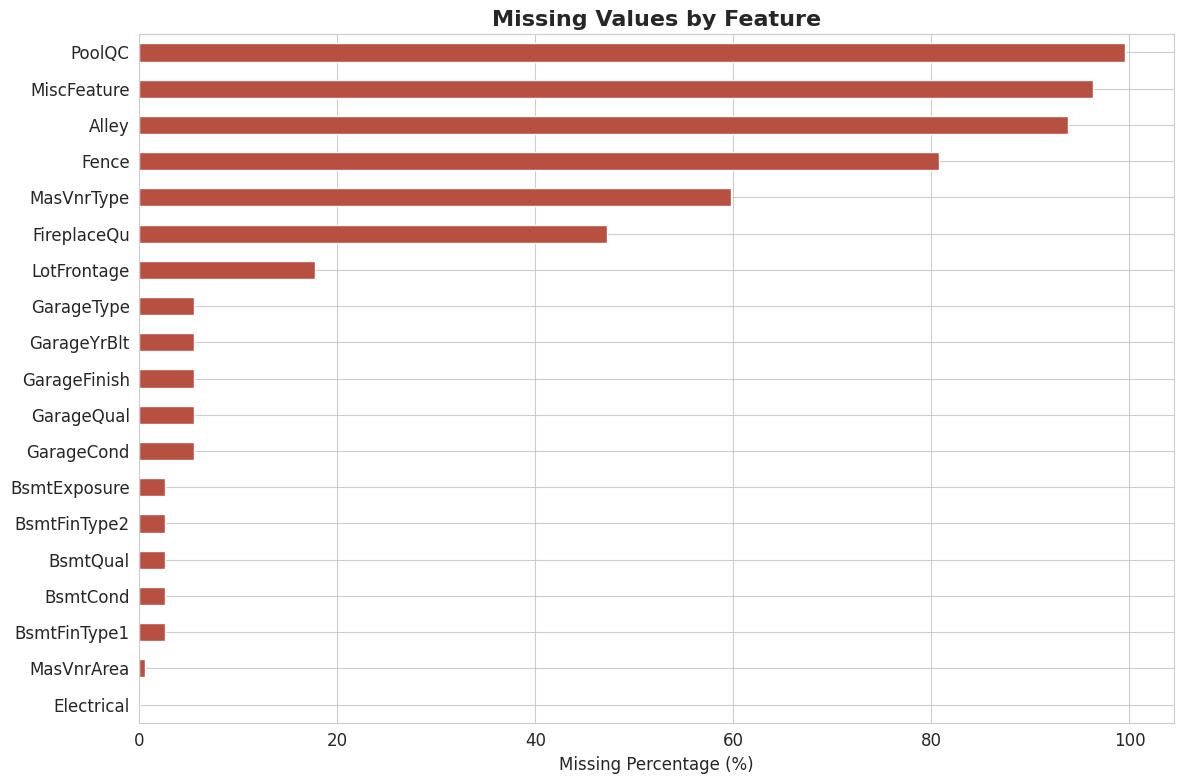

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
missing_pct.plot(kind='barh', color='#B85042', ax=ax)
ax.set_xlabel('Missing Percentage (%)')
ax.set_title('Missing Values by Feature', fontsize=16, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
high_missing = missing_pct[missing_pct > 50].index.tolist()
medium_missing = missing_pct[(missing_pct > 5) & (missing_pct <= 50)].index.tolist()
low_missing = missing_pct[missing_pct <= 5].index.tolist()

print("HIGH missing (>50% — will drop):")
for col in high_missing:
    print(f"  {col}: {missing_pct[col]}%")

print(f"\nMEDIUM missing (5-50% — needs strategy):")
for col in medium_missing:
    print(f"  {col}: {missing_pct[col]}%")

print(f"\nLOW missing (<5% — simple imputation):")
for col in low_missing:
    print(f"  {col}: {missing_pct[col]}%")

HIGH missing (>50% — will drop):
  PoolQC: 99.52%
  MiscFeature: 96.3%
  Alley: 93.77%
  Fence: 80.75%
  MasVnrType: 59.73%

MEDIUM missing (5-50% — needs strategy):
  FireplaceQu: 47.26%
  LotFrontage: 17.74%
  GarageType: 5.55%
  GarageYrBlt: 5.55%
  GarageFinish: 5.55%
  GarageQual: 5.55%
  GarageCond: 5.55%

LOW missing (<5% — simple imputation):
  BsmtExposure: 2.6%
  BsmtFinType2: 2.6%
  BsmtQual: 2.53%
  BsmtCond: 2.53%
  BsmtFinType1: 2.53%
  MasVnrArea: 0.55%
  Electrical: 0.07%


SalePrice Statistics:
count      1458.00
mean     180932.92
std       79495.06
min       34900.00
25%      129925.00
50%      163000.00
75%      214000.00
max      755000.00
Name: SalePrice, dtype: float64


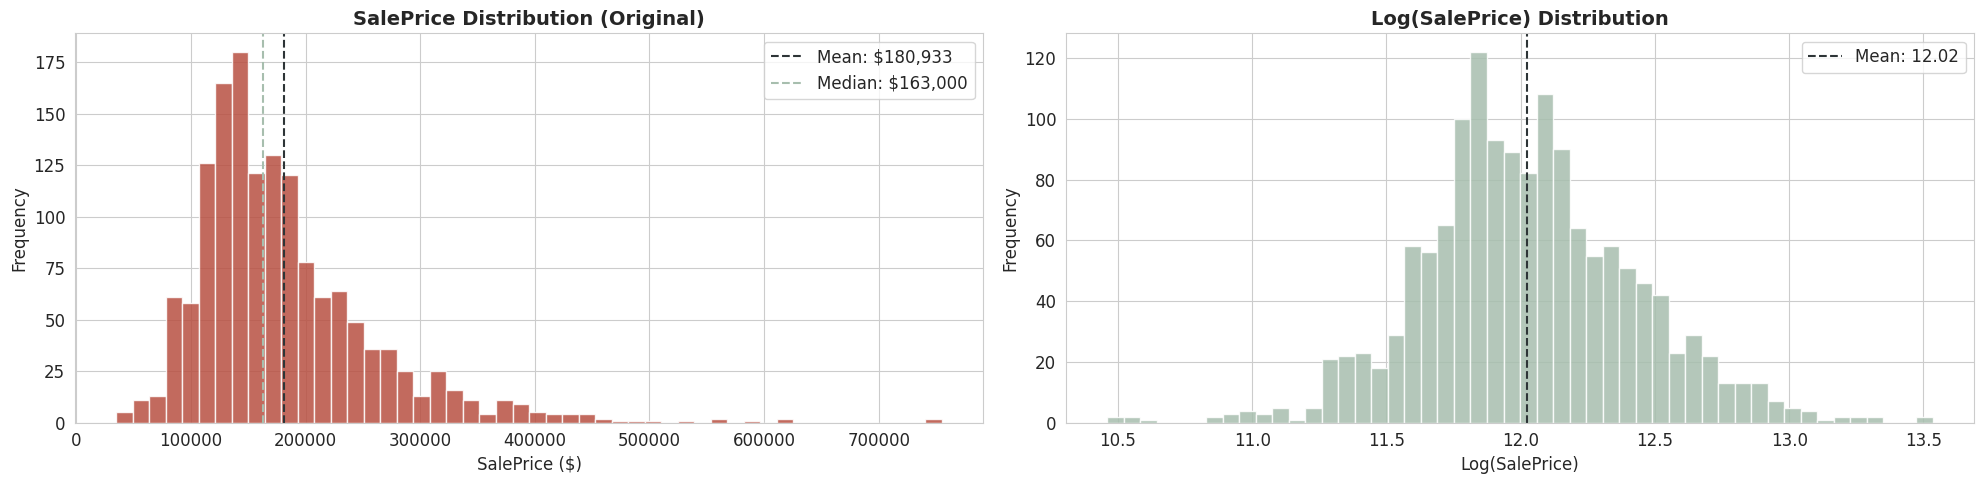


Original skewness:1.8813
Log-transformed skewness: 0.1216

 Log transformation significantly reduces skewness.


In [ ]:
print("SalePrice Statistics:")
print(train['SalePrice'].describe().round(2))


fig, axes = plt.subplots(1, 2, figsize=(20, 5))

axes[0].hist(train['SalePrice'], bins=50, color='#B85042', edgecolor='white', alpha=0.85)
axes[0].set_title('SalePrice Distribution (Original)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('SalePrice ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(train['SalePrice'].mean(), color='#2D3436', linestyle='--',
                label=f"Mean: ${train['SalePrice'].mean():,.0f}")
axes[0].axvline(train['SalePrice'].median(), color='#A7BEAE', linestyle='--',
                label=f"Median: ${train['SalePrice'].median():,.0f}")
axes[0].legend()

log_price = np.log1p(train['SalePrice'])
axes[1].hist(log_price, bins=50, color='#A7BEAE', edgecolor='white', alpha=0.85)
axes[1].set_title('Log(SalePrice) Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Log(SalePrice)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(log_price.mean(), color='#2D3436', linestyle='--',
                label=f"Mean: {log_price.mean():.2f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('saleprice_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nOriginal skewness:{train['SalePrice'].skew():.4f}")
print(f"Log-transformed skewness: {log_price.skew():.4f}")
print("\n Log transformation significantly reduces skewness.")

Outliers found: 2 observations
Dataset shape BEFORE removal: (1460, 81)
Dataset shape AFTER removal:  (1458, 81)


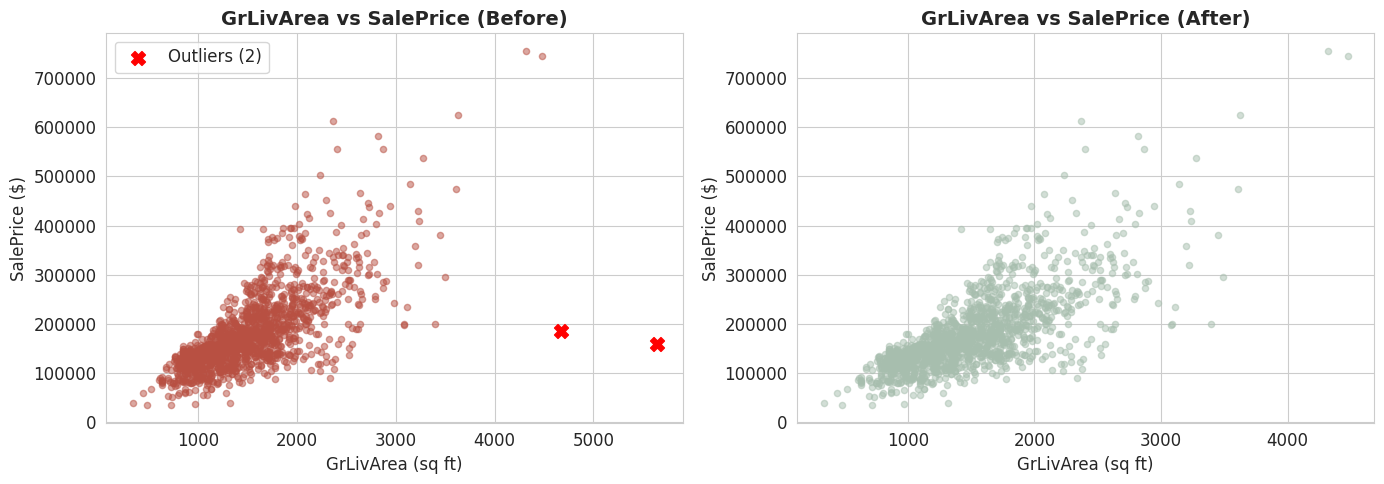

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(train['GrLivArea'], train['SalePrice'], alpha=0.5, c='#B85042', s=20)
axes[0].set_title('GrLivArea vs SalePrice (Before)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('GrLivArea (sq ft)')
axes[0].set_ylabel('SalePrice ($)')

outliers = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)]
axes[0].scatter(outliers['GrLivArea'], outliers['SalePrice'], c='red', s=100,
                marker='X', label=f'Outliers ({len(outliers)})', zorder=5)
axes[0].legend()

print(f"Outliers found: {len(outliers)} observations")
print(f"Dataset shape BEFORE removal: {train.shape}")
train = train.drop(outliers.index)
print(f"Dataset shape AFTER removal:  {train.shape}")

axes[1].scatter(train['GrLivArea'], train['SalePrice'], alpha=0.5, c='#A7BEAE', s=20)
axes[1].set_title('GrLivArea vs SalePrice (After)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('GrLivArea (sq ft)')
axes[1].set_ylabel('SalePrice ($)')

plt.tight_layout()
plt.savefig('outlier_removal.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
correlations = train[numerical_cols + ['SalePrice']].corr()['SalePrice'].drop('SalePrice')
correlations = correlations.abs().sort_values(ascending=False)

print("Top 15 features correlated with SalePrice:")
print("-" * 45)
for feat, corr in correlations.head(15).items():
    print(f"  {feat:25s}  r = {corr:.4f}")

Top 15 features correlated with SalePrice:
---------------------------------------------
  OverallQual                r = 0.7958
  GrLivArea                  r = 0.7029
  TotalBsmtSF                r = 0.6512
  GarageCars                 r = 0.6410
  GarageArea                 r = 0.6292
  1stFlrSF                   r = 0.5985
  FullBath                   r = 0.5622
  TotRmsAbvGrd               r = 0.5378
  YearBuilt                  r = 0.5236
  YearRemodAdd               r = 0.5077
  Fireplaces                 r = 0.4699
  GarageYrBlt                r = 0.4674
  OpenPorchSF                r = 0.4310
  MasVnrArea                 r = 0.4063
  LotArea                    r = 0.3922


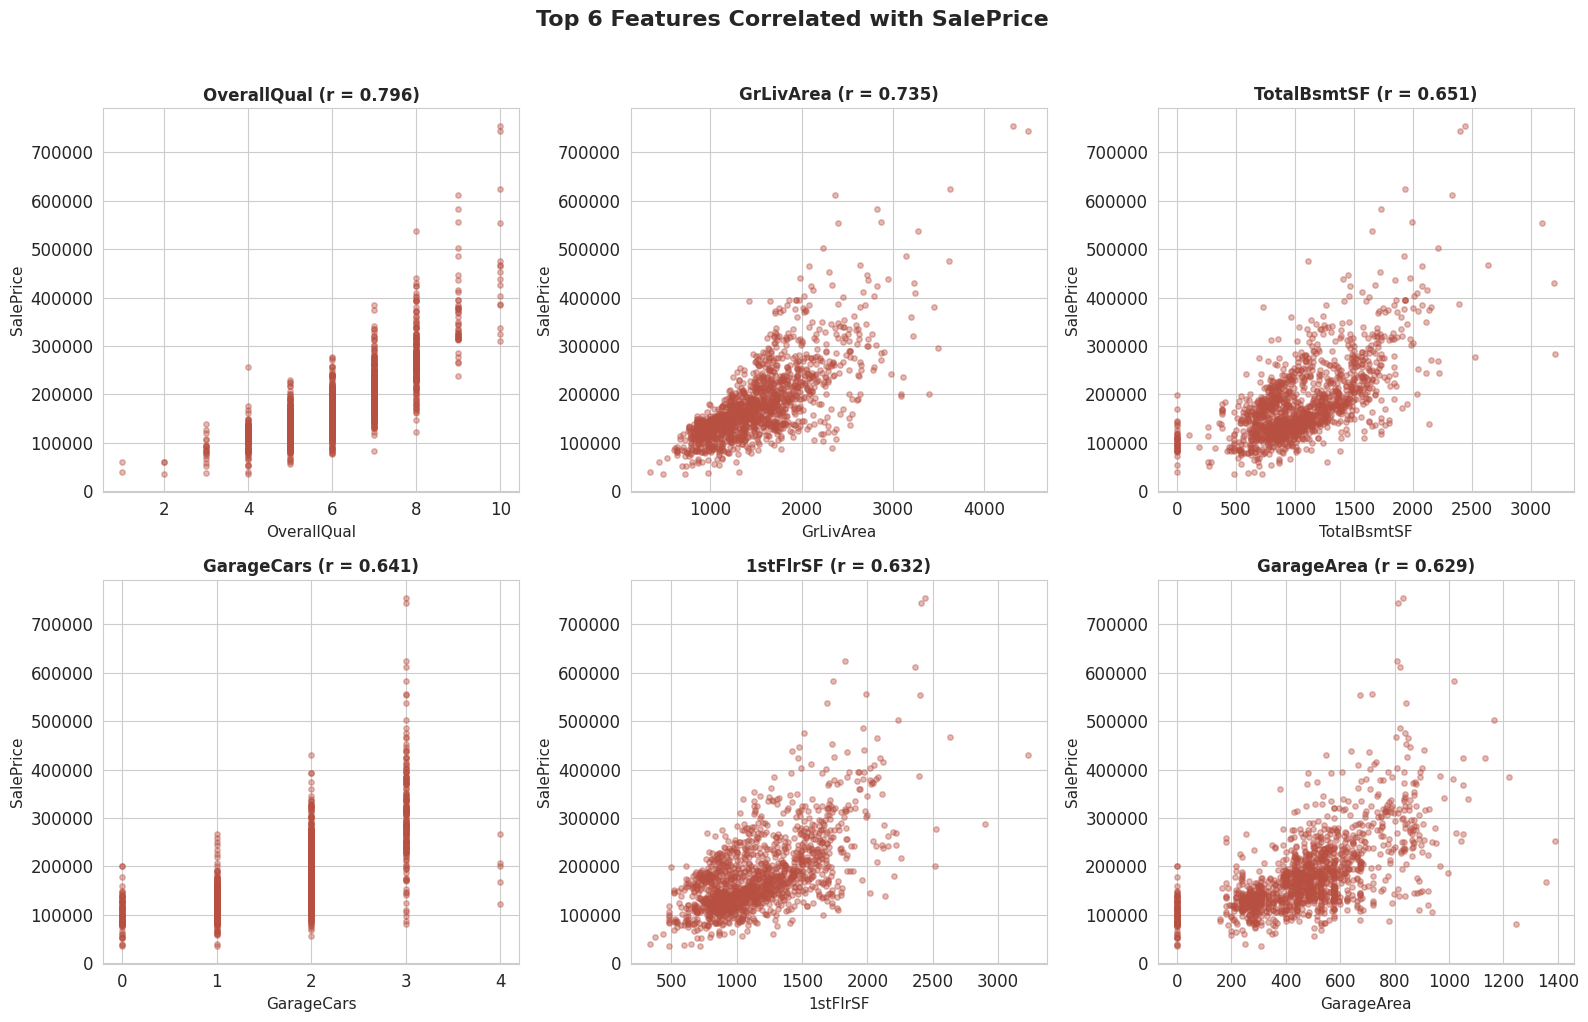

In [ ]:
top_6 = correlations.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(top_6):
    axes[i].scatter(train[feat], train['SalePrice'], alpha=0.4, c='#B85042', s=15)
    axes[i].set_xlabel(feat, fontsize=11)
    axes[i].set_ylabel('SalePrice', fontsize=11)
    r = train[feat].corr(train['SalePrice'])
    axes[i].set_title(f'{feat} (r = {r:.3f})', fontsize=12, fontweight='bold')

plt.suptitle('Top 6 Features Correlated with SalePrice', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('top_features_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

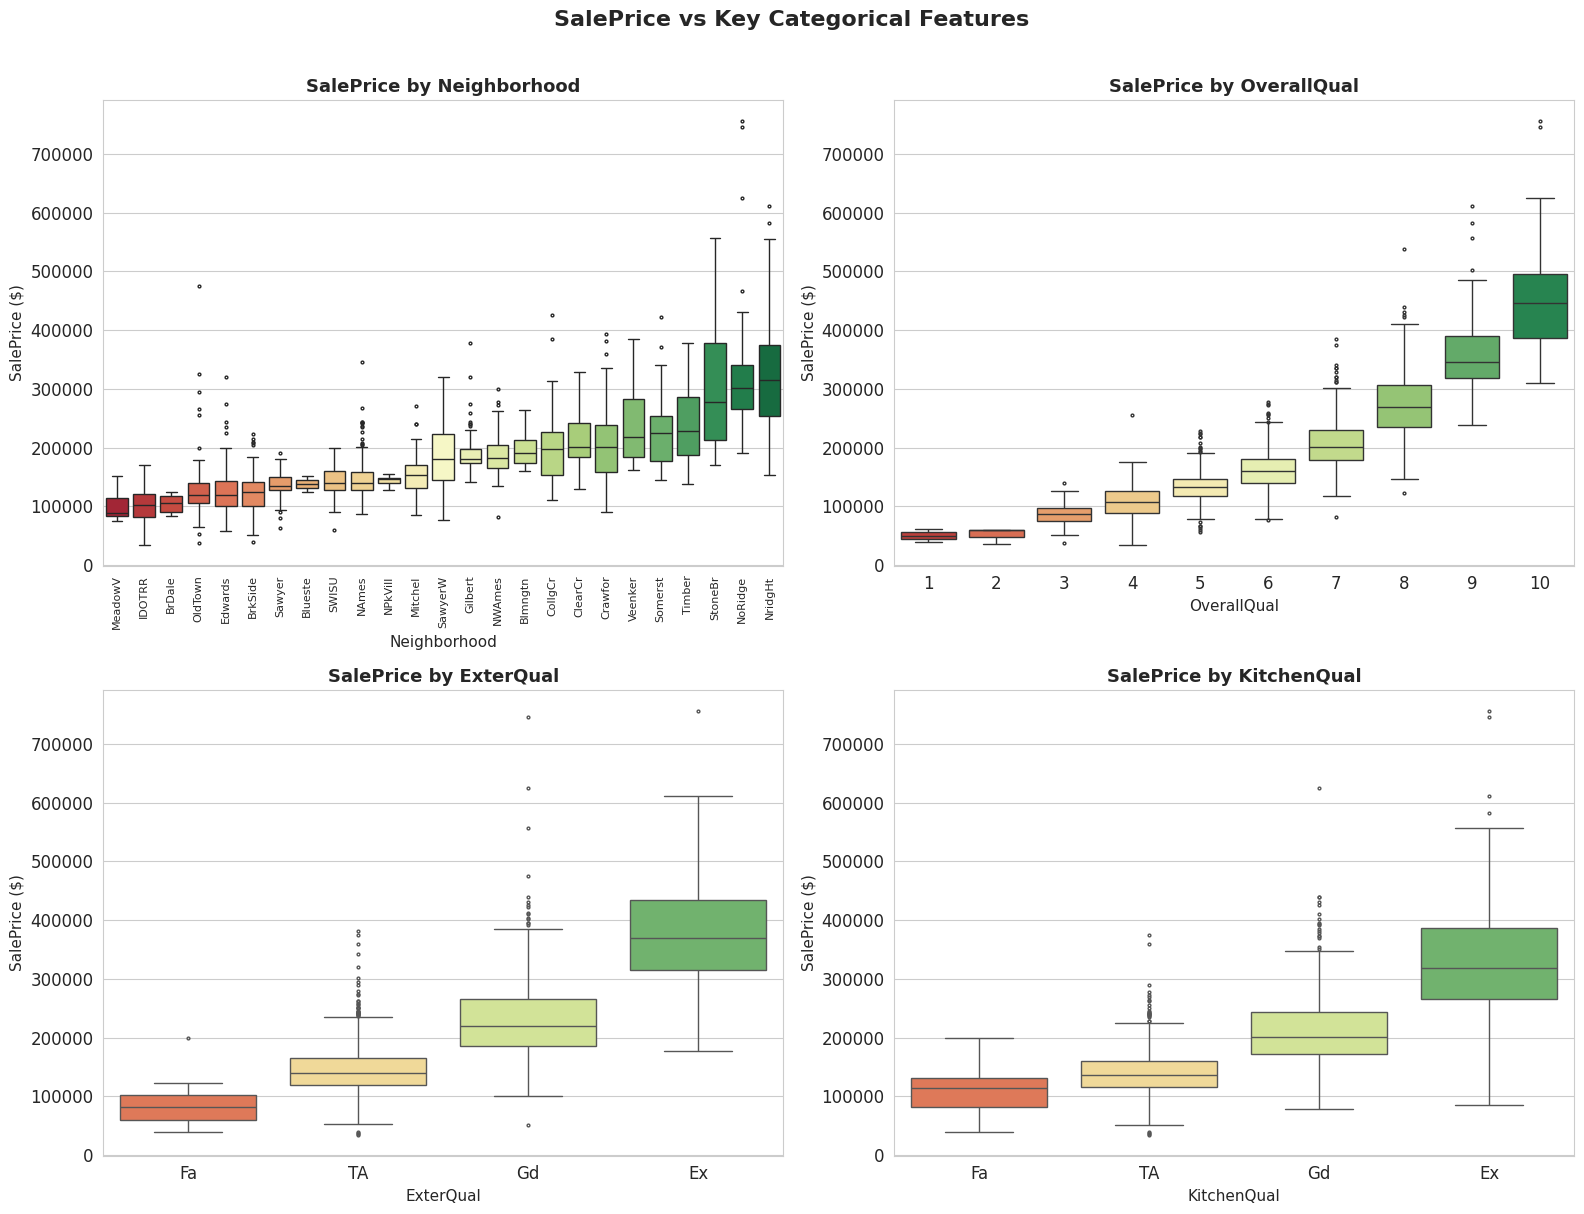

In [ ]:
key_cats = ['Neighborhood', 'OverallQual', 'ExterQual', 'KitchenQual']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feat in enumerate(key_cats):
    if feat == 'Neighborhood':
        order = train.groupby('Neighborhood')['SalePrice'].median().sort_values().index
        sns.boxplot(x=feat, y='SalePrice', data=train, order=order,
                    ax=axes[i], palette='RdYlGn', fliersize=2)
        axes[i].tick_params(axis='x', rotation=90, labelsize=8)
    elif feat == 'OverallQual':
        sns.boxplot(x=feat, y='SalePrice', data=train, ax=axes[i],
                    palette='RdYlGn', fliersize=2)
    else:
        order = train.groupby(feat)['SalePrice'].median().sort_values().index
        sns.boxplot(x=feat, y='SalePrice', data=train, order=order,
                    ax=axes[i], palette='RdYlGn', fliersize=2)
    axes[i].set_title(f'SalePrice by {feat}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(feat, fontsize=11)
    axes[i].set_ylabel('SalePrice ($)', fontsize=11)

plt.suptitle('SalePrice vs Key Categorical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('categorical_features.png', dpi=150, bbox_inches='tight')
plt.show()

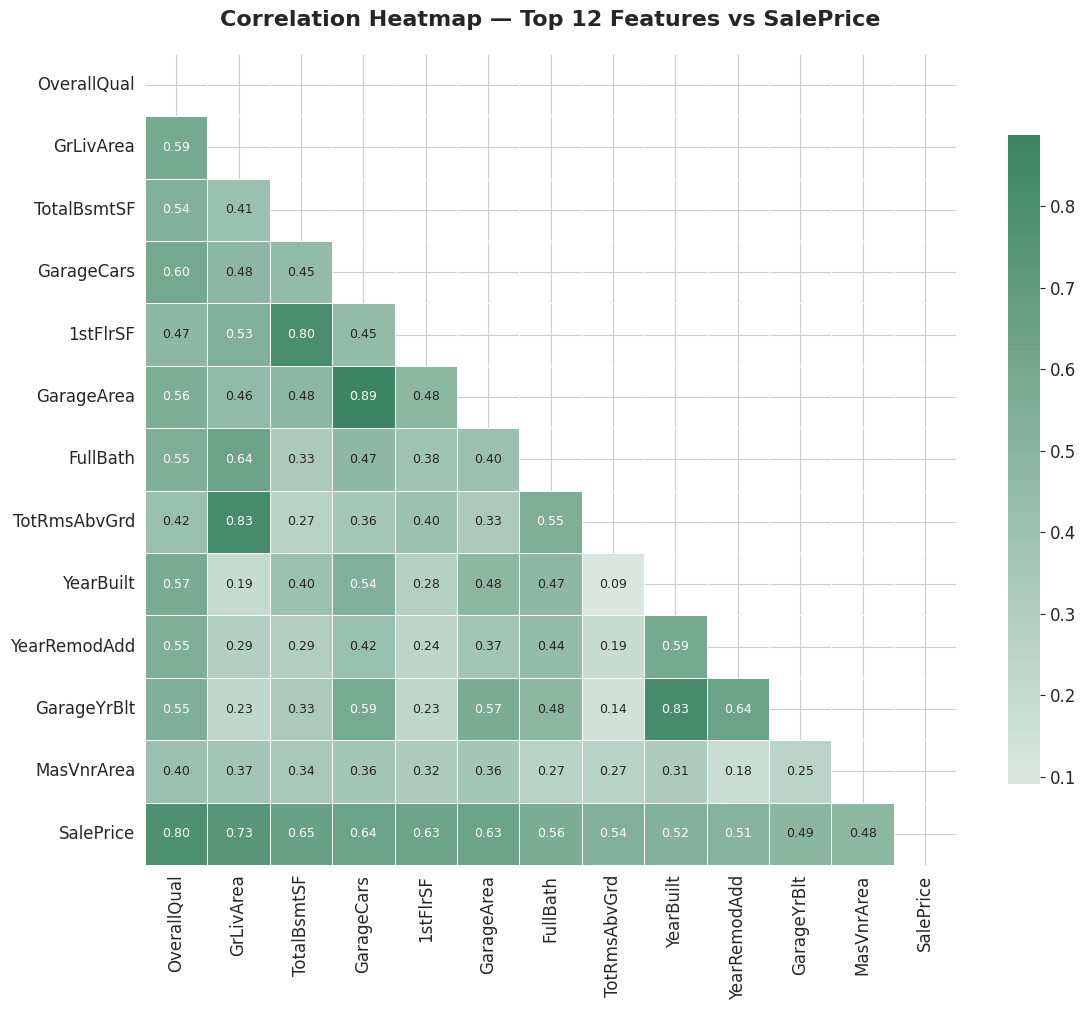


Multicollinearity check (pairs with |r| > 0.7):
-----------------------------------------------------------------
  GrLivArea            <-> TotRmsAbvGrd          r = 0.829
  TotalBsmtSF          <-> 1stFlrSF              r = 0.804
  GarageCars           <-> GarageArea            r = 0.887
  YearBuilt            <-> GarageYrBlt           r = 0.825


In [ ]:
top_12 = correlations.head(12).index.tolist() + ['SalePrice']
corr_matrix = train[top_12].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(10, 150, as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, cmap=cmap, center=0,
            annot=True, fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, ax=ax, annot_kws={"size": 9})
ax.set_title('Correlation Heatmap — Top 12 Features vs SalePrice',
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMulticollinearity check (pairs with |r| > 0.7):")
print("-" * 65)
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7 and corr_matrix.columns[j] != 'SalePrice':
            print(f"  {corr_matrix.columns[i]:20s} <-> {corr_matrix.columns[j]:20s}  r = {corr_matrix.iloc[i, j]:.3f}")

In [ ]:
missing_after = train.isnull().sum()
missing_after = missing_after[missing_after > 0].sort_values(ascending=False)
missing_after_pct = (missing_after / len(train) * 100).round(2)

# Drop columns with >50% missing
cols_to_drop = missing_after_pct[missing_after_pct > 50].index.tolist()
print(f"DROPPING columns with >50% missing: {cols_to_drop}")
train = train.drop(columns=cols_to_drop)

# NA means "None" for these columns (no garage, no basement, etc.)
none_cols = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'FireplaceQu', 'MasVnrType']

print(f"\nFilling 'None' for NA-means-no-feature columns:")
for col in none_cols:
    if col in train.columns:
        count = train[col].isnull().sum()
        if count > 0:
            train[col] = train[col].fillna('None')
            print(f"  {col}: filled {count} values")

# Numerical columns — fill with median
num_missing = [col for col in train.columns
               if train[col].isnull().sum() > 0 and train[col].dtype in ['int64', 'float64']]
print(f"\nMedian imputation for numerical columns:")
for col in num_missing:
    count = train[col].isnull().sum()
    median_val = train[col].median()
    train[col] = train[col].fillna(median_val)
    print(f"  {col}: filled {count} values with median={median_val}")

# Remaining categorical — fill with mode
cat_missing = [col for col in train.columns
               if train[col].isnull().sum() > 0 and train[col].dtype == 'object']
print(f"\nMode imputation for remaining categorical columns:")
for col in cat_missing:
    count = train[col].isnull().sum()
    mode_val = train[col].mode()[0]
    train[col] = train[col].fillna(mode_val)
    print(f"  {col}: filled {count} values with mode='{mode_val}'")

print(f"\nRemaining missing values: {train.isnull().sum().sum()}")
print(f"Final dataset shape: {train.shape}")

DROPPING columns with >50% missing: ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType']

Filling 'None' for NA-means-no-feature columns:
  GarageType: filled 81 values
  GarageFinish: filled 81 values
  GarageQual: filled 81 values
  GarageCond: filled 81 values
  BsmtQual: filled 37 values
  BsmtCond: filled 37 values
  BsmtExposure: filled 38 values
  BsmtFinType1: filled 37 values
  BsmtFinType2: filled 38 values
  FireplaceQu: filled 690 values

Median imputation for numerical columns:
  LotFrontage: filled 259 values with median=69.0
  MasVnrArea: filled 8 values with median=0.0
  GarageYrBlt: filled 81 values with median=1980.0

Mode imputation for remaining categorical columns:
  Electrical: filled 1 values with mode='SBrkr'

Remaining missing values: 0
Final dataset shape: (1458, 76)


In [ ]:
print("New Feature Examples\n")

train['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
print("TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF")

train['HouseAge'] = train['YrSold'] - train['YearBuilt']
print("HouseAge = YrSold - YearBuilt")

train['RemodAge'] = train['YrSold'] - train['YearRemodAdd']
print("RemodAge = YrSold - YearRemodAdd")

train['TotalBath'] = (train['FullBath'] + (0.5 * train['HalfBath']) +
                      train['BsmtFullBath'] + (0.5 * train['BsmtHalfBath']))
print("TotalBath = FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath")

train['TotalPorchSF'] = (train['OpenPorchSF'] + train['EnclosedPorch'] +
                         train['3SsnPorch'] + train['ScreenPorch'])
print("TotalPorchSF = OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch")

train['HasPool'] = (train['PoolArea'] > 0).astype(int)
train['HasGarage'] = (train['GarageArea'] > 0).astype(int)
train['HasFireplace'] = (train['Fireplaces'] > 0).astype(int)
train['HasBsmt'] = (train['TotalBsmtSF'] > 0).astype(int)
train['Has2ndFlr'] = (train['2ndFlrSF'] > 0).astype(int)
print("Binary flags: HasPool, HasGarage, HasFireplace, HasBsmt, Has2ndFlr")

print(f"\nCorrelation of new features with SalePrice:")
for feat in ['TotalSF', 'HouseAge', 'RemodAge', 'TotalBath', 'TotalPorchSF']:
    r = train[feat].corr(train['SalePrice'])
    print(f"  {feat:20s}  r = {r:.4f}")

New Feature Examples

TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF
HouseAge = YrSold - YearBuilt
RemodAge = YrSold - YearRemodAdd
TotalBath = FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath
TotalPorchSF = OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch
Binary flags: HasPool, HasGarage, HasFireplace, HasBsmt, Has2ndFlr

Correlation of new features with SalePrice:
  TotalSF               r = 0.6542
  HouseAge              r = -0.5241
  RemodAge              r = -0.5097
  TotalBath             r = 0.6364
  TotalPorchSF          r = 0.2744


In [ ]:
numerical_feats = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_feats = [f for f in numerical_feats if f not in ['Id', 'SalePrice']]

skewed = train[numerical_feats].apply(lambda x: x.skew()).sort_values(ascending=False)
highly_skewed = skewed[abs(skewed) > 0.75]
print(f"Highly skewed features (|skew| > 0.75): {len(highly_skewed)}")
print(highly_skewed.head(10))

print(f"\nApplying log1p transformation to {len(highly_skewed)} skewed features...")
for feat in highly_skewed.index:
    if (train[feat] >= 0).all():
        train[feat] = np.log1p(train[feat])
print("Done!")

Highly skewed features (|skew| > 0.75): 25
MiscVal         24.460085
PoolArea        15.948945
HasPool         15.508026
LotArea         12.573925
3SsnPorch       10.297106
LowQualFinSF     9.004955
KitchenAbvGr     4.484883
BsmtFinSF2       4.251925
ScreenPorch      4.118929
BsmtHalfBath     4.100114
dtype: float64

Applying log1p transformation to 25 skewed features...
Done!


In [ ]:
train.to_csv('train_cleaned.csv', index=False)

print("=" * 60)
print("EDA & DATA CLEANING COMPLETE")
print("=" * 60)
print(f"\nFinal dataset shape: {train.shape}")
print(f"Missing values: {train.isnull().sum().sum()}")
print(f"\nSaved to: train_cleaned.csv")
print(f"\nVisualizations saved:")
print(f"  1. missing_values.png")
print(f"  2. saleprice_distribution.png")
print(f"  3. outlier_removal.png")
print(f"  4. top_features_scatter.png")
print(f"  5. categorical_features.png")
print(f"  6. correlation_heatmap.png")

EDA & DATA CLEANING COMPLETE

Final dataset shape: (1458, 86)
Missing values: 0

Saved to: train_cleaned.csv

Visualizations saved:
  1. missing_values.png
  2. saleprice_distribution.png
  3. outlier_removal.png
  4. top_features_scatter.png
  5. categorical_features.png
  6. correlation_heatmap.png
